# 04 — Learned embeddings

**Dataset:** `drive_day_2026`

**Question:** Does masked reconstruction learn useful recurrence neighborhoods?

## Method

Train compact temporal encoder on training recordings only, then inspect held-out reconstruction and neighbors.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_learned import render_embedding_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {'epochs': 20}
EXPERIMENT_OPTIONS

{'epochs': 20}

,task,split,metric,value,sample_count,reference_source
0,masked_signal_prediction,train,mean_reconstruction_mse,0.547548,333,none
1,masked_signal_prediction,validation,mean_reconstruction_mse,0.453776,108,none
2,masked_signal_prediction,test,mean_reconstruction_mse,0.439399,59,none
3,masked_signal_prediction,all,mean_reconstruction_mse,0.514532,500,none
4,embedding_retrieval,train,mean_neighbor_cosine_similarity,0.999081,333,none
5,embedding_retrieval,validation,mean_neighbor_cosine_similarity,0.998952,108,none
6,embedding_retrieval,test,mean_neighbor_cosine_similarity,0.999702,59,none
7,embedding_retrieval,all,mean_neighbor_cosine_similarity,0.999127,500,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,500,21,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,500,500,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,500.0,NaN,NaN,NaN,43.528,49.015163,0.0,11.5,27.0,54.0,218.0
end_s,500.0,NaN,NaN,NaN,53.528,49.015163,10.0,21.5,37.0,64.0,228.0
prediction_kind,500,1,masked_prediction_embedding_neighbor,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,500.0,NaN,NaN,NaN,0.999127,0.00284,0.9788,0.999843,0.999985,0.999998,1.0
label_status,500,1,provisional_unverified,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbor_recording_id,500,21,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbor_start_s,500.0,NaN,NaN,NaN,37.116,38.572246,0.0,10.0,26.0,50.0,216.0
temporal_separation_s,500.0,NaN,NaN,NaN,42.924,44.784434,0.0,14.0,26.0,52.0,212.0


,count,mean,median,std,min,max
recording_id,,,,,,
554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa703e0c50db726bae3b,5,1.000000,1.000000,1.916615e-09,1.000000,1.000000
953f71ef131b4c5ce7211560abcbafbfe0079e72cf2190c2908d3ff00cf5db12,40,1.000000,1.000000,5.650306e-07,0.999996,1.000000
382db1f8ede73f956341d7b461790125339762ec9d7cc96480f20aefe04d77e1,24,1.000000,1.000000,1.260299e-07,1.000000,1.000000
564a12f3d813c10242613a907d2b4981e7296739ba9a560571b3547dab1daa7f,24,0.999999,1.000000,1.903234e-06,0.999993,1.000000
1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316416ecbf000289fd40a,7,0.999996,0.999997,2.555368e-06,0.999991,0.999999
07173121b1534f1eadb8b127005d4eff70872388074c2bbe0c93061527d89f40,7,0.999989,0.999995,1.467829e-05,0.999957,0.999999
2f775054c4e7bb342cf49e0ee66406e82353c274c103fc7f7d6a93ea329aea86,9,0.999991,0.999994,6.959354e-06,0.999976,0.999997
4c8d0190b666e26315ce16c862ca2e968d576e14537487162bbd73b9a47d0c07,7,0.999988,0.999993,1.550017e-05,0.999954,0.999998
e57d3de89d6f2a3165aa05beee7b611f60923e090254337c1b48f744c78db52d,24,0.999490,0.999990,1.612953e-03,0.993205,1.000000


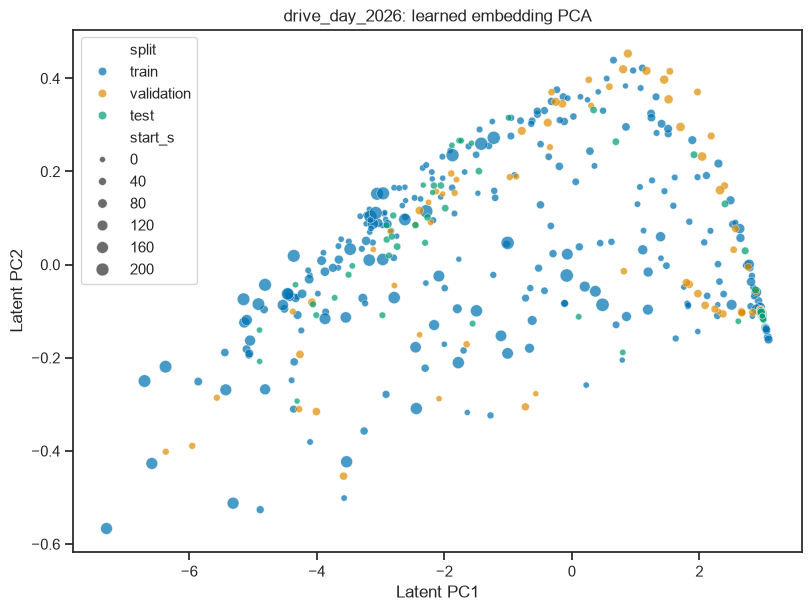

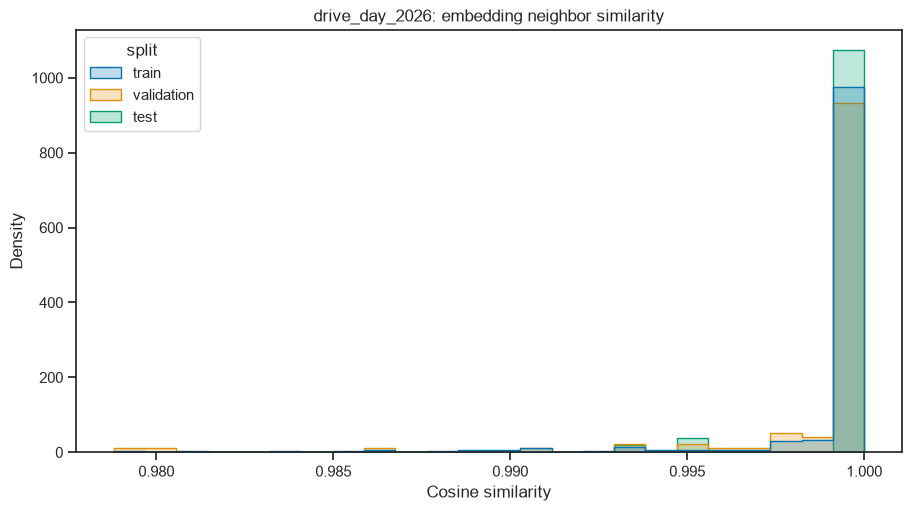

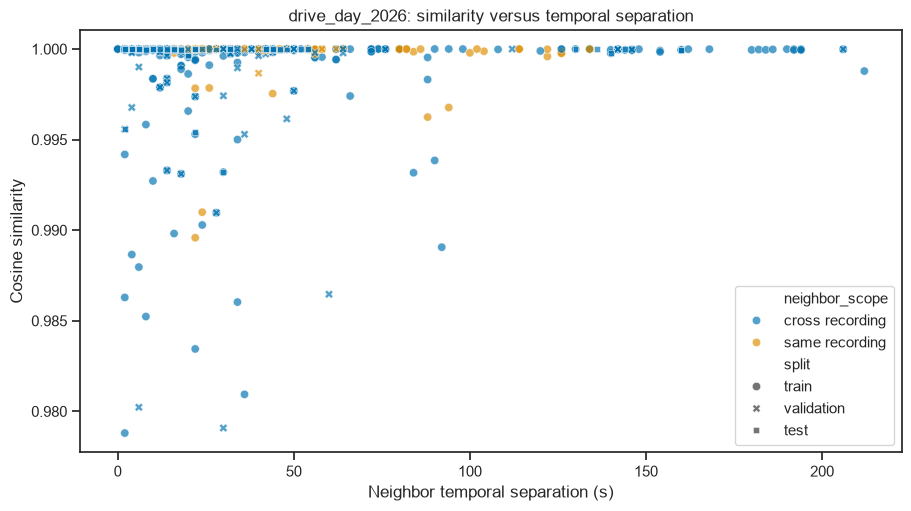

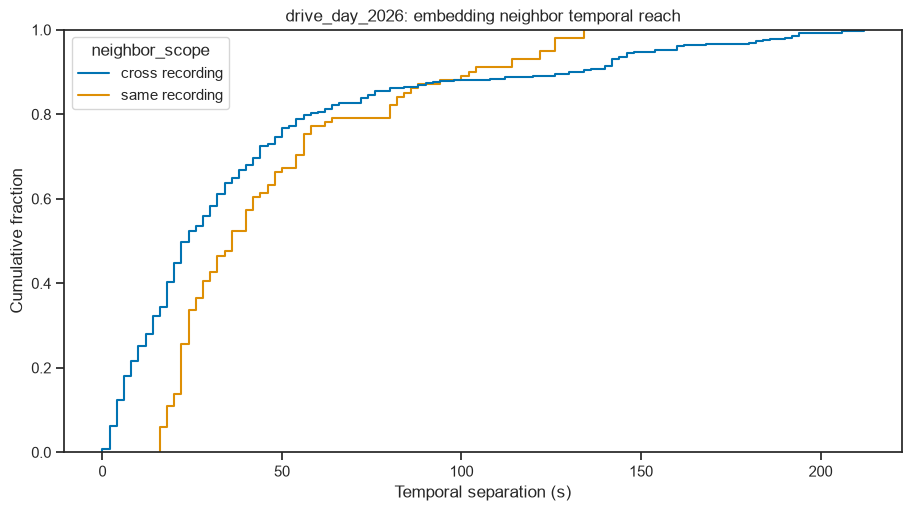

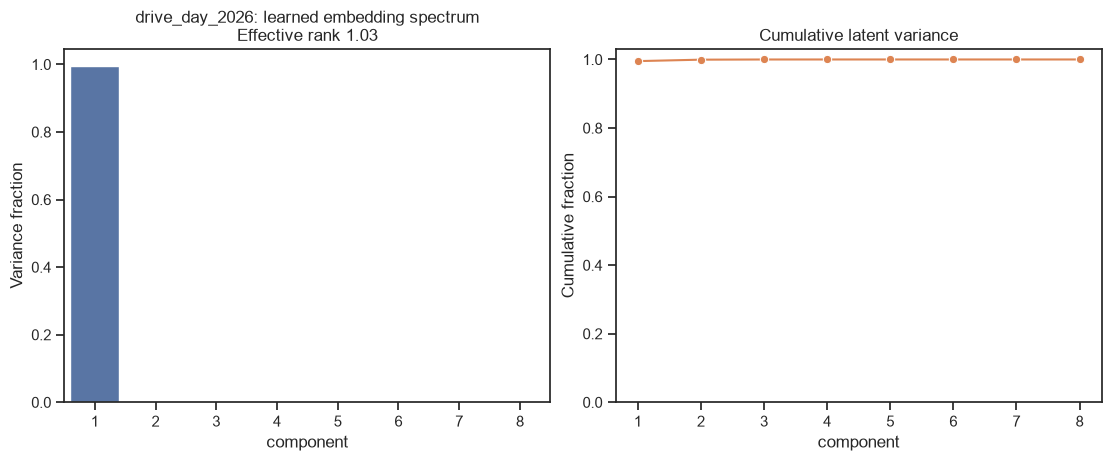

In [3]:
METHOD = "04_learned_embeddings"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_embedding_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,5.161
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,self_supervised_unverified


## Reading

Near-unity similarity may reflect overlapping windows or collapse. Reconstruction is not lap accuracy.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.